In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import copy
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision 
from torchvision import transforms

import defHelp

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("torchvision:", torchvision.__version__)
print(f"device: {device}")

torch: 2.10.0+cpu
cuda: None
torchvision: 0.25.0+cpu
device: cpu


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if title == "modelE4 history":
        plt.savefig("./artifacts/figures/curves_best.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logists = model(x)
        loss = criterion(logists, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device): 
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logists = model(x)
        loss = criterion(logists, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_acc": [],  "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_acc"].append(tr_acc)
        history["train_loss"].append(tr_loss)
        history["val_acc"].append(val_acc)
        history["val_loss"].append(val_loss)

        if verbose:
            print(
                    f"epoch {epoch:02d}/{epochs} | "
                    f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                    f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
                )
        
        if early_stopping is not None:
            if early_stopping.step(val_acc, model):
                if verbose:
                    print(f"Остановка на эпохе {epoch};\nСворачиваем всю порнографиб, лучший результат: val_acc={early_stopping.best_score}")
                early_stopping.restore_best(model)
                break

    return history


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_full = torchvision.datasets.EMNIST(split="balanced", root="./data", train=True, download=False, transform=transform)
test_ds = torchvision.datasets.EMNIST(split="balanced", root="./data", train=False, download=False, transform=transform)

class_names = train_full.classes
print(f"classes: {train_full.classes}, ({len(class_names)})")
print(f"train size: {len(train_full)}")
print(f"test size: {len(test_ds)}")


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'], (47)
train size: 112800
test size: 18800


In [4]:
BATCH_SIZE = 128
NUM_WORKERS = 6
gen = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(train_full, [int(len(train_full) * 0.8), len(train_full) - int(len(train_full) * 0.8)], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory="False")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory="False")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory="False")

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x_batch: torch.Size([128, 1, 28, 28]), torch.float32
y_batch: torch.Size([128]), torch.int64


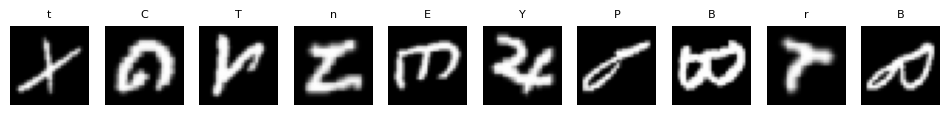

In [5]:
def show_images(loader, n=10):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.1307 + 0.3081
        plt.imshow(img, cmap="gray")
        plt.title(train_full.classes[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)
    

In [6]:
class MLP(nn.Module):
    def __init__(
            self, 
            input_dim=28*28,
            hidden_dims=(512, 256, 128),
            num_classes=47,
            activation="relu",
            dropout_p=0.0,
            use_batchnorm=False):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


epoch 01/20 | train loss=0.9689, acc=0.7057 | val loss=0.6401, acc=0.7874
epoch 02/20 | train loss=0.5413, acc=0.8176 | val loss=0.5413, acc=0.8200
epoch 03/20 | train loss=0.4473, acc=0.8437 | val loss=0.4719, acc=0.8427
epoch 04/20 | train loss=0.3894, acc=0.8601 | val loss=0.4600, acc=0.8461
epoch 05/20 | train loss=0.3493, acc=0.8709 | val loss=0.4749, acc=0.8430
epoch 06/20 | train loss=0.3214, acc=0.8786 | val loss=0.4864, acc=0.8438
epoch 07/20 | train loss=0.2932, acc=0.8862 | val loss=0.4870, acc=0.8420
epoch 08/20 | train loss=0.2704, acc=0.8938 | val loss=0.4865, acc=0.8479
epoch 09/20 | train loss=0.2546, acc=0.8980 | val loss=0.5069, acc=0.8462
epoch 10/20 | train loss=0.2421, acc=0.9016 | val loss=0.5235, acc=0.8426
epoch 11/20 | train loss=0.2247, acc=0.9085 | val loss=0.5640, acc=0.8438
epoch 12/20 | train loss=0.2160, acc=0.9117 | val loss=0.5544, acc=0.8432
epoch 13/20 | train loss=0.2105, acc=0.9131 | val loss=0.5866, acc=0.8422
epoch 14/20 | train loss=0.1970, acc=0

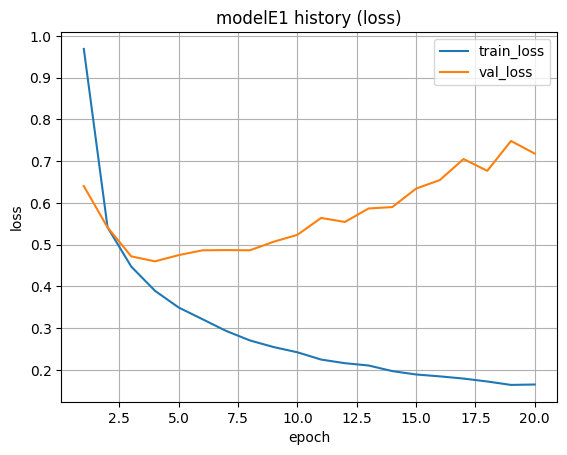

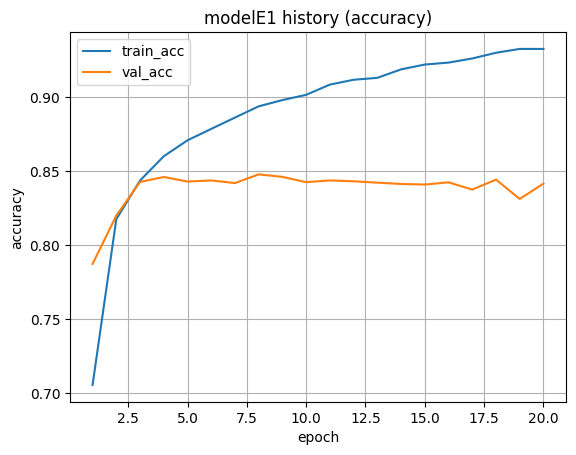

In [7]:
modelE1 = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE1.parameters(), lr=1e-3)

history_E1 = fit(modelE1, train_loader, val_loader, optimizer, criterion, device)

plot_history(history_E1, "modelE1 history")

In [8]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "E1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": False},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_E1["val_acc"]),
    "best_val_loss": min(history_E1["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)


In [9]:
best_acc = 0.0
history_best_modelE2 = None
best_modelE2 = None

for p in (0.2, 0.3, 0.4, 0.5):
    modelE2 = MLP(dropout_p=p).to(device)
    optimizer = optim.Adam(modelE2.parameters(), lr=1e-3)
    
    print(f"{p}:")
    history_E2 = fit(modelE2, train_loader, val_loader, optimizer, criterion, device)
    if max(history_E2["val_acc"]) > best_acc:
        history_best_modelE2 = history_E2
        best_modelE2 = copy.deepcopy(modelE2)
        best_acc = max(history_E2["val_acc"])
     

0.2:


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/20 | train loss=1.1987, acc=0.6400 | val loss=0.6360, acc=0.7930
epoch 02/20 | train loss=0.6878, acc=0.7770 | val loss=0.5359, acc=0.8217
epoch 03/20 | train loss=0.5968, acc=0.8024 | val loss=0.4945, acc=0.8343
epoch 04/20 | train loss=0.5377, acc=0.8181 | val loss=0.4789, acc=0.8362
epoch 05/20 | train loss=0.5128, acc=0.8249 | val loss=0.4738, acc=0.8409
epoch 06/20 | train loss=0.4801, acc=0.8322 | val loss=0.4588, acc=0.8483
epoch 07/20 | train loss=0.4628, acc=0.8380 | val loss=0.4468, acc=0.8521
epoch 08/20 | train loss=0.4459, acc=0.8436 | val loss=0.4459, acc=0.8509
epoch 09/20 | train loss=0.4313, acc=0.8451 | val loss=0.4602, acc=0.8458
epoch 10/20 | train loss=0.4232, acc=0.8497 | val loss=0.4490, acc=0.8540
epoch 11/20 | train loss=0.4085, acc=0.8530 | val loss=0.4461, acc=0.8532
epoch 12/20 | train loss=0.4013, acc=0.8545 | val loss=0.4590, acc=0.8516
epoch 13/20 | train loss=0.3936, acc=0.8574 | val loss=0.4378, acc=0.8545
epoch 14/20 | train loss=0.3858, acc=0

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.2, inplace=False)
    (10): Linear(in_features=128, out_features=47, bias=True)
  )
)


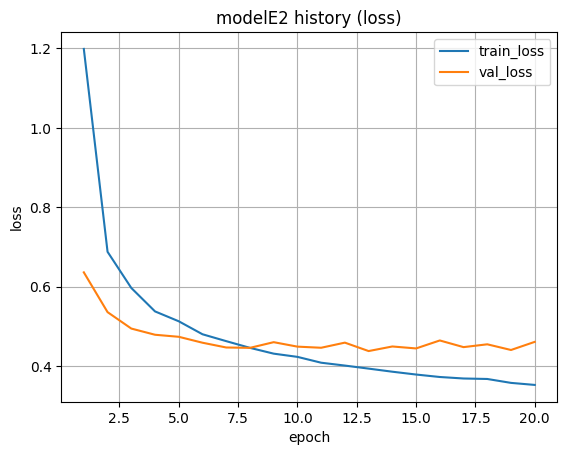

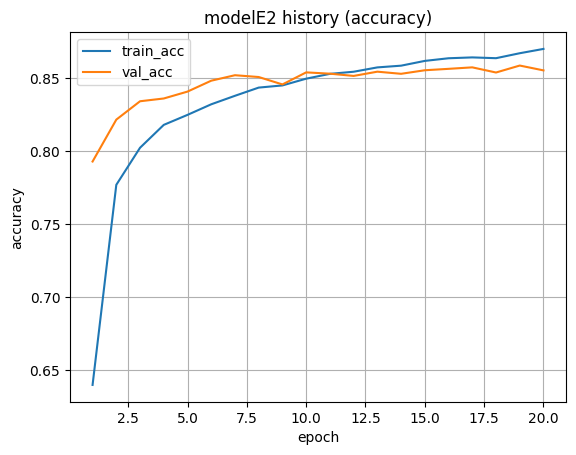

In [10]:
print(best_modelE2)
plot_history(history_best_modelE2, "modelE2 history")

In [11]:
new_row = {
    "experiment_id": "E2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.3, 
                      "batchnorm": False},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_best_modelE2["val_acc"]),
    "best_val_loss": min(history_best_modelE2["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/20 | train loss=0.8980, acc=0.7467 | val loss=0.5469, acc=0.8184
epoch 02/20 | train loss=0.4877, acc=0.8331 | val loss=0.4797, acc=0.8376
epoch 03/20 | train loss=0.4102, acc=0.8554 | val loss=0.4569, acc=0.8458
epoch 04/20 | train loss=0.3639, acc=0.8674 | val loss=0.4360, acc=0.8479
epoch 05/20 | train loss=0.3305, acc=0.8765 | val loss=0.4399, acc=0.8498
epoch 06/20 | train loss=0.3019, acc=0.8855 | val loss=0.4367, acc=0.8502
epoch 07/20 | train loss=0.2815, acc=0.8910 | val loss=0.4352, acc=0.8538
epoch 08/20 | train loss=0.2599, acc=0.8991 | val loss=0.4404, acc=0.8545
epoch 09/20 | train loss=0.2425, acc=0.9035 | val loss=0.4568, acc=0.8502
epoch 10/20 | train loss=0.2313, acc=0.9079 | val loss=0.4612, acc=0.8525
epoch 11/20 | train loss=0.2163, acc=0.9131 | val loss=0.4612, acc=0.8533
epoch 12/20 | train loss=0.2041, acc=0.9167 | val loss=0.4877, acc=0.8514
epoch 13/20 | train loss=0.1964, acc=0.9186 | val loss=0.4875, acc=0.8532
epoch 14/20 | train loss=0.1873, acc=0

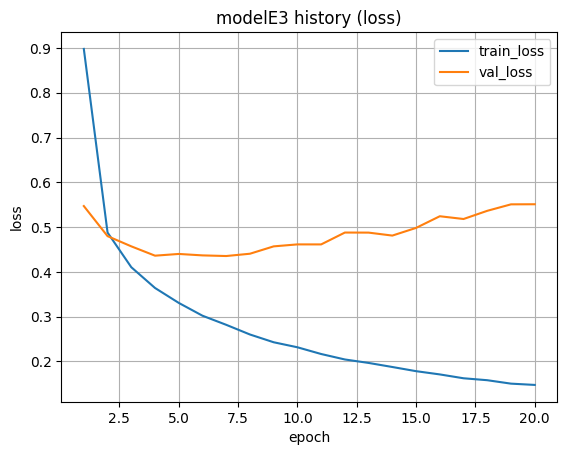

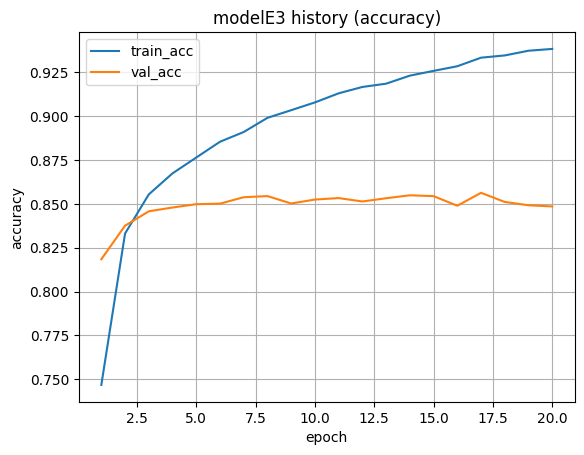

In [12]:
modelE3 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE3.parameters(), lr=1e-3)

history_E3 = fit(modelE3, train_loader, val_loader, optimizer, criterion, device)

plot_history(history_E3, "modelE3 history")

In [13]:
new_row = {
    "experiment_id": "E3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_E3["val_acc"]),
    "best_val_loss": min(history_E3["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

In [14]:
modelE4 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE4.parameters(), lr=1e-3)

history_E4 = fit(modelE4, train_loader, val_loader, optimizer, criterion, device, early_stopping=EarlyStopping(patience=5), epochs=100)


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/100 | train loss=0.8935, acc=0.7488 | val loss=0.5463, acc=0.8176
epoch 02/100 | train loss=0.4877, acc=0.8349 | val loss=0.4746, acc=0.8366
epoch 03/100 | train loss=0.4111, acc=0.8552 | val loss=0.4532, acc=0.8444
epoch 04/100 | train loss=0.3626, acc=0.8679 | val loss=0.4442, acc=0.8492
epoch 05/100 | train loss=0.3298, acc=0.8776 | val loss=0.4326, acc=0.8533
epoch 06/100 | train loss=0.3018, acc=0.8855 | val loss=0.4299, acc=0.8548
epoch 07/100 | train loss=0.2797, acc=0.8919 | val loss=0.4356, acc=0.8540
epoch 08/100 | train loss=0.2604, acc=0.8974 | val loss=0.4385, acc=0.8558
epoch 09/100 | train loss=0.2437, acc=0.9039 | val loss=0.4492, acc=0.8534
epoch 10/100 | train loss=0.2307, acc=0.9085 | val loss=0.4515, acc=0.8558
epoch 11/100 | train loss=0.2164, acc=0.9130 | val loss=0.4662, acc=0.8548
epoch 12/100 | train loss=0.2041, acc=0.9166 | val loss=0.4828, acc=0.8500
epoch 13/100 | train loss=0.1930, acc=0.9213 | val loss=0.4920, acc=0.8510
epoch 14/100 | train loss

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=47, bias=True)
  )
)


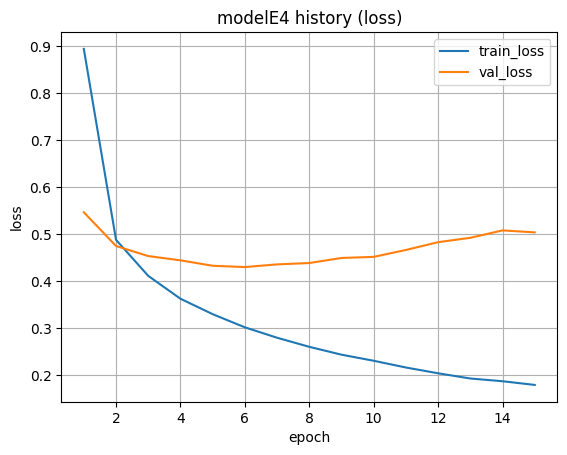

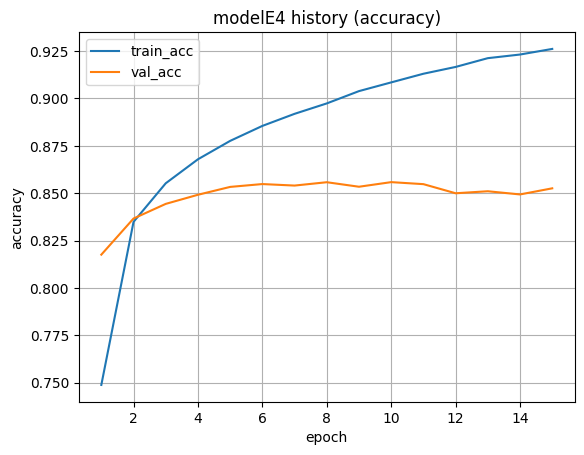

In [15]:
print(modelE4)
plot_history(history_E4, "modelE4 history")

In [ ]:
new_row = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 14,
    "best_val_accuracy": max(history_E4["val_acc"]),
    "best_val_loss": min(history_E4["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

torch.save(modelE4.state_dict(), "./artifacts/best_model.pt")

config_best_model = {
    "dataset": "EMNIST",
    "seed": 42,
    "type": "MLP",
    "input_dim": 28*28,
    "hidden_dims": (512, 256, 128),
    "activation": "ReLU",
    "dropout": 0.0,
    "batchnorm": True,
    "num_classes": 47,
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs": 14,
    "batch_size": 128
}

with open("./artifacts/best_config.json", "w") as f:
    json.dump(config_best_model, f, indent=4)

In [17]:
best_model = MLP(use_batchnorm=True).to(device)
state_dict = torch.load("./artifacts/best_model.pt", map_location="cpu")
best_model.load_state_dict(state_dict)
evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(0.46586846757908257, 0.8547360909228422)

epoch 01/8 | train loss=1.6998, acc=0.5147 | val loss=1.0166, acc=0.6788
epoch 02/8 | train loss=1.0256, acc=0.6873 | val loss=0.9595, acc=0.7125
epoch 03/8 | train loss=0.8919, acc=0.7274 | val loss=0.7776, acc=0.7578
epoch 04/8 | train loss=0.8112, acc=0.7505 | val loss=0.8093, acc=0.7613
epoch 05/8 | train loss=0.7684, acc=0.7626 | val loss=0.6748, acc=0.7794
epoch 06/8 | train loss=0.7712, acc=0.7644 | val loss=0.7716, acc=0.7794
epoch 07/8 | train loss=0.7062, acc=0.7805 | val loss=0.7863, acc=0.7704
epoch 08/8 | train loss=0.6908, acc=0.7862 | val loss=0.6857, acc=0.7922


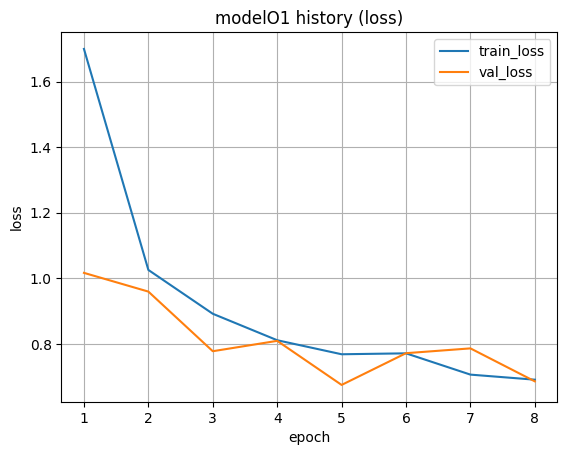

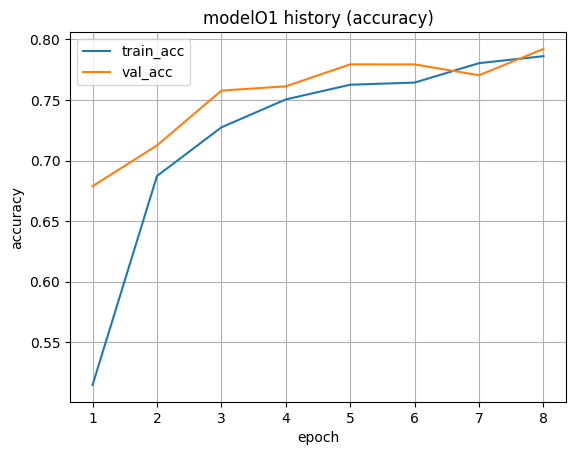

In [18]:
modelO1 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelO1.parameters(), lr=0.3)

history_O1 = fit(modelO1, train_loader, val_loader, optimizer, criterion, device, epochs=8)
plot_history(history_O1, "modelO1 history")

In [19]:
new_row = {
    "experiment_id": "O1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 0.3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 8,
    "best_val_accuracy": max(history_O1["val_acc"]),
    "best_val_loss": min(history_O1["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/8 | train loss=3.8423, acc=0.0381 | val loss=3.7555, acc=0.0563
epoch 02/8 | train loss=3.6772, acc=0.0776 | val loss=3.6012, acc=0.1080
epoch 03/8 | train loss=3.5355, acc=0.1370 | val loss=3.4675, acc=0.1702
epoch 04/8 | train loss=3.4156, acc=0.1991 | val loss=3.3616, acc=0.2281
epoch 05/8 | train loss=3.3125, acc=0.2554 | val loss=3.2651, acc=0.2782
epoch 06/8 | train loss=3.2230, acc=0.3001 | val loss=3.1789, acc=0.3227
epoch 07/8 | train loss=3.1430, acc=0.3388 | val loss=3.1078, acc=0.3558
epoch 08/8 | train loss=3.0701, acc=0.3715 | val loss=3.0332, acc=0.3879


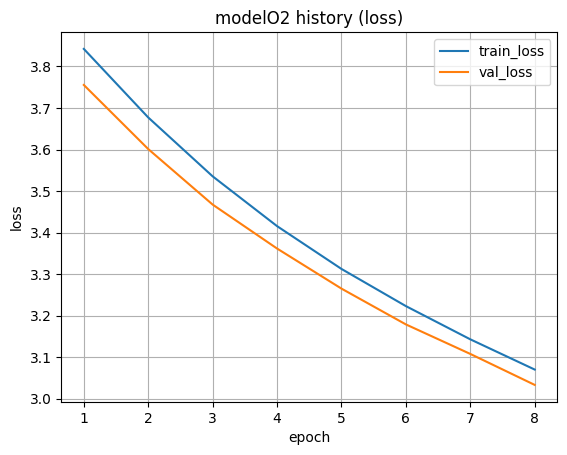

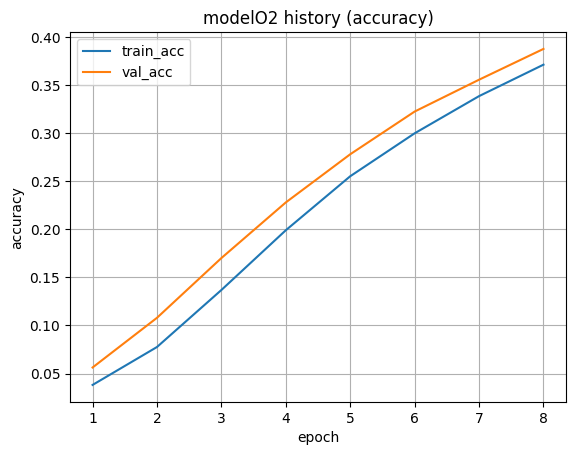

In [20]:
modelO2 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelO2.parameters(), lr=1e-6)

history_O2 = fit(modelO2, train_loader, val_loader, optimizer, criterion, device, epochs=8)
plot_history(history_O2, "modelO2 history")

In [21]:
new_row = {
    "experiment_id": "O2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-6,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 8,
    "best_val_accuracy": max(history_O2["val_acc"]),
    "best_val_loss": min(history_O2["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_22456\3448262373.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


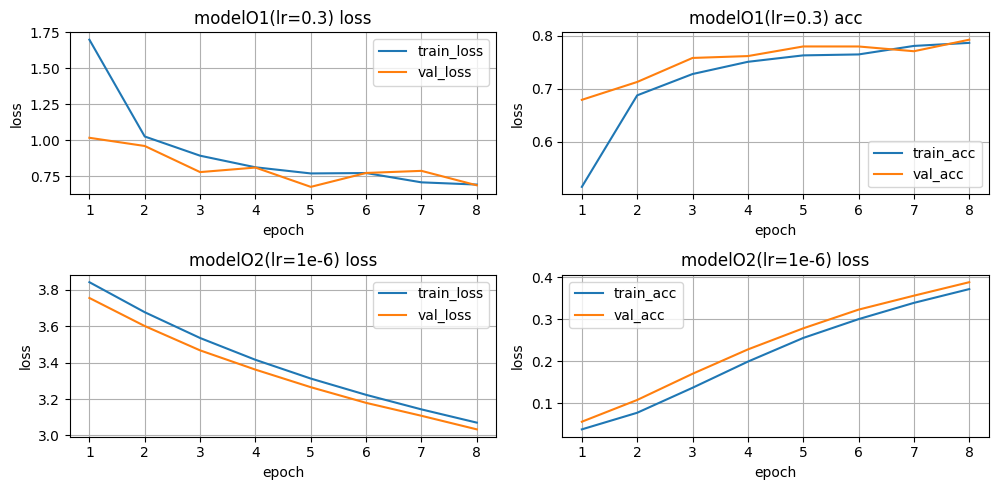

In [22]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

ax[0, 0].plot(np.arange(1, 9), history_O1["train_loss"], label="train_loss")
ax[0, 0].plot(np.arange(1, 9), history_O1["val_loss"], label="val_loss")
ax[0, 0].set_xlabel("epoch")
ax[0, 0].set_ylabel("loss")
ax[0, 0].set_title("modelO1(lr=0.3) loss")
ax[0, 0].legend()
ax[0, 0].grid(True)
ax[0, 1].plot(np.arange(1, 9), history_O1["train_acc"], label="train_acc")
ax[0, 1].plot(np.arange(1, 9), history_O1["val_acc"], label="val_acc")
ax[0, 1].set_xlabel("epoch")
ax[0, 1].set_ylabel("loss")
ax[0, 1].set_title("modelO1(lr=0.3) acc")
ax[0, 1].legend()
ax[0, 1].grid(True)
ax[1, 0].plot(np.arange(1, 9), history_O2["train_loss"], label="train_loss")
ax[1, 0].plot(np.arange(1, 9), history_O2["val_loss"], label="val_loss")
ax[1, 0].set_xlabel("epoch")
ax[1, 0].set_ylabel("loss")
ax[1, 0].set_title("modelO2(lr=1e-6) loss")
ax[1, 0].legend()
ax[1, 0].grid(True)
ax[1, 1].plot(np.arange(1, 9), history_O2["train_acc"], label="train_acc")
ax[1, 1].plot(np.arange(1, 9), history_O2["val_acc"], label="val_acc")
ax[1, 1].set_xlabel("epoch")
ax[1, 1].set_ylabel("loss")
ax[1, 1].set_title("modelO2(lr=1e-6) loss")
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.savefig("./artifacts/figures/curves_lr_extremes.png")
fig.show()


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/15 | train loss=2.2807, acc=0.5250 | val loss=1.4286, acc=0.6912
epoch 02/15 | train loss=1.1315, acc=0.7287 | val loss=0.9091, acc=0.7651
epoch 03/15 | train loss=0.8041, acc=0.7830 | val loss=0.7309, acc=0.7927
epoch 04/15 | train loss=0.6584, acc=0.8110 | val loss=0.6380, acc=0.8118
epoch 05/15 | train loss=0.5706, acc=0.8312 | val loss=0.5838, acc=0.8206
epoch 06/15 | train loss=0.5110, acc=0.8441 | val loss=0.5501, acc=0.8280
epoch 07/15 | train loss=0.4653, acc=0.8561 | val loss=0.5268, acc=0.8313
epoch 08/15 | train loss=0.4301, acc=0.8648 | val loss=0.5072, acc=0.8371
epoch 09/15 | train loss=0.3997, acc=0.8731 | val loss=0.4959, acc=0.8385
epoch 10/15 | train loss=0.3757, acc=0.8787 | val loss=0.4829, acc=0.8429
epoch 11/15 | train loss=0.3512, acc=0.8858 | val loss=0.4776, acc=0.8426
epoch 12/15 | train loss=0.3310, acc=0.8921 | val loss=0.4748, acc=0.8438
epoch 13/15 | train loss=0.3148, acc=0.8960 | val loss=0.4699, acc=0.8436
epoch 14/15 | train loss=0.2983, acc=0

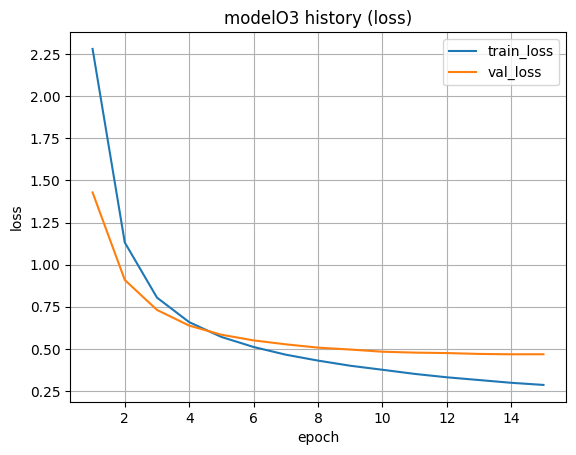

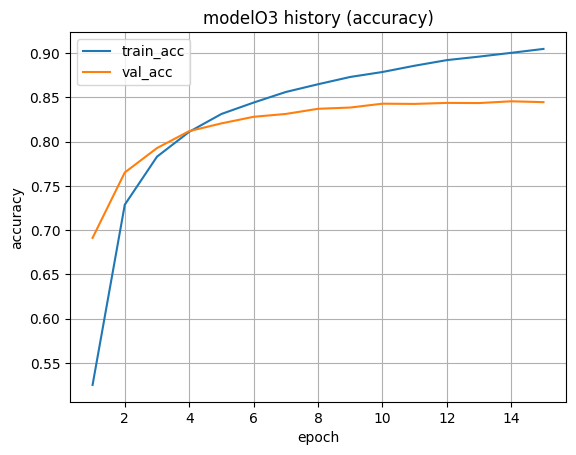

In [23]:
modelO3 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(modelO3.parameters(), momentum=0.9, weight_decay=1e-4, lr=1e-3)

history_O3 = fit(modelO3, train_loader, val_loader, optimizer, criterion, device, epochs=15)
plot_history(history_O3, "modelO3 history")

In [24]:
new_row = {
    "experiment_id": "O3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "SGD",
    "lr": 1e-3,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs_trained": 15,
    "best_val_accuracy": max(history_O3["val_acc"]),
    "best_val_loss": min(history_O3["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)